# Лабораторная работа 7. Полносвязные нейронные сети (FCNN). Решение задачи регрессии

## Загрузка данных и понижение размерности

Прежде, чем обучать модели на данных, дополним их предобработку.

Для улучшения производительности обучения нейронных сетей применим стандартизацию к данным. Отметим, что в ходе выполнения прошлых лабораторных работ к данным было применено MinMax-масштабирование, но стандартизация  может значительно повысить производительность при обучении нейронной сети.

После этого выполним оптимизацию пространства признаков с помощью VarianceThreshold. Это уменьшит призанковое пространство ровно на 1 признак.

In [1]:
import pickle

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import optuna
from matplotlib.lines import lineStyles
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearnex.model_selection import train_test_split
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import seaborn as sns
import keras


C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("datasets/air.csv", index_col = 0)

X, y = data.drop("CO(GT)", axis=1), data["CO(GT)"]



selector_vt = VarianceThreshold(threshold=0.015)
X_vt = selector_vt.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vt)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

print(f"Исходные признаки: {X.columns.tolist()}, количество: {len(X.columns.tolist())}")
print(f"Признаки после понижения размерности: {X.columns[selector_vt.get_support()].tolist()},"
      f" количество: {len(X.columns[selector_vt.get_support()].tolist())}")

Исходные признаки: ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'day', 'month', 'day_of_week', 'hour', 'year'], количество: 15
Признаки после понижения размерности: ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'day', 'month', 'day_of_week', 'hour', 'year'], количество: 14


## FCNN (MLP) из библиотеки Scikit-learn

In [17]:
columns = [
    'Regressor', 'Search strategy',
    'Train_R2', 'Train_MSE', 'Train_MAE',
    'Test_R2', 'Test_MSE', 'Test_MAE', 'Epochs', 'Solver'
]
table = pd.DataFrame(columns=columns)
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver


In [4]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


def input_into_table(name, search_name, model, X_train, y_train, X_test, y_test):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    new_row = {
        'Regressor': name,
        'Search strategy': search_name,
        'Train_R2': round(r2_score(y_train, train_pred), 2),
        'Train_MSE': round(mean_squared_error(y_train, train_pred), 4),
        'Train_MAE': round(mean_absolute_error(y_train, train_pred), 4),
        'Test_R2': round(r2_score(y_test, test_pred), 2),
        'Test_MSE': round(mean_squared_error(y_test, test_pred), 4),
        'Test_MAE': round(mean_absolute_error(y_test, test_pred), 4),
        'Epochs': model.n_iter_,
        'Solver': model.solver
    }

    table.loc[len(table)] = new_row

### Optuna

Опишем гиперпараметры, которые будут настраиваться для настроек модели.

*   **hidden_layer_sizes**: Поиск оптимальной глубины сети от одного до трех скрытых слоев.
*   **solver**: Сравнение оптимизаторов (`adam`, `sgd`, `lbfgs`) для нахождения глобального минимума ошибки.
*   **activation**: Выбор функции активации (`relu`, `tanh`) для моделирования нелинейных зависимостей.
*   **alpha**: Подбор коэффициента L2-регуляризации для контроля переобучения.
*   **learning_rate**: Настройка режима изменения шага обучения (постоянный или адаптивный).
*   **learning_rate_init**: Оптимизация начальной скорости сходимости алгоритма.


In [18]:
solvers = ['adam', 'sgd', 'lbfgs']
best_models_optuna = {}
for current_solver in solvers:
    def objective(trial):
        params = {
            'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes',
                                                            [(100,), (50, 50), (100, 50), (100, 100, 100)]),

            # 'solver': trial.suggest_categorical('solver', ['adam', 'sgd', 'lbfgs']),

            'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),

            'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),

            'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        }

        params['solver'] = current_solver

        regressor = MLPRegressor(**params, random_state=15, max_iter=1000)

        score = cross_val_score(regressor, X_train, y_train, cv=5, n_jobs=-1, scoring="r2").mean()

        return score

    study = optuna.create_study(direction="maximize")

    study.optimize(objective, n_trials=15)

    print(f"Лучшие параметры для {current_solver}: {study.best_params}")


    final_params = study.best_params
    final_params['solver'] = current_solver
    best_models_optuna[current_solver] = model


    model = MLPRegressor(**final_params, random_state=15, max_iter=1000)
    model.fit(X_train, y_train)

    model_name = f"MLPRegressor ({current_solver})"
    input_into_table(model_name, "Optuna", model, X_train, y_train, X_test, y_test)

    print(f"Лучшие параметры для MLPRegressor ({current_solver}): {study.best_params}")

[I 2026-05-16 06:08:13,029] A new study created in memory with name: no-name-08ab639e-fba3-4450-9983-7521085e94ea
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  optuna_warn(messa

Лучшие параметры для adam: {'hidden_layer_sizes': (100, 100, 100), 'activation': 'relu', 'alpha': 0.004469352347500357, 'learning_rate': 'constant'}


[I 2026-05-16 06:08:24,385] A new study created in memory with name: no-name-efc855bd-1b7f-4cf5-811c-51992ce50aea


Лучшие параметры для MLPRegressor (adam): {'hidden_layer_sizes': (100, 100, 100), 'activation': 'relu', 'alpha': 0.004469352347500357, 'learning_rate': 'constant'}


C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarni

Лучшие параметры для sgd: {'hidden_layer_sizes': (100, 100, 100), 'activation': 'tanh', 'alpha': 0.00496646190016159, 'learning_rate': 'adaptive'}


[I 2026-05-16 06:09:05,562] A new study created in memory with name: no-name-52331e5e-c77a-402a-8b28-63d6d7af7bda


Лучшие параметры для MLPRegressor (sgd): {'hidden_layer_sizes': (100, 100, 100), 'activation': 'tanh', 'alpha': 0.00496646190016159, 'learning_rate': 'adaptive'}


C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarni

Лучшие параметры для lbfgs: {'hidden_layer_sizes': (100, 100, 100), 'activation': 'relu', 'alpha': 0.008958617552740597, 'learning_rate': 'adaptive'}
Лучшие параметры для MLPRegressor (lbfgs): {'hidden_layer_sizes': (100, 100, 100), 'activation': 'relu', 'alpha': 0.008958617552740597, 'learning_rate': 'adaptive'}


In [19]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor (adam),Optuna,0.91,0.0009,0.0216,0.87,0.0013,0.0248,19,adam
1,MLPRegressor (sgd),Optuna,0.54,0.0048,0.0518,0.55,0.0046,0.0506,81,sgd
2,MLPRegressor (lbfgs),Optuna,0.91,0.0009,0.0217,0.88,0.0013,0.0241,106,lbfgs


Видим, что нейросети с настройкой через фреймворк Optuna с оптимизаторами adam и lbfgs показали отличные результаты метрик - на тестовой выборке R2 = 0.88 и R2 = 0.87.

In [32]:
model = best_models_optuna["adam"]
n_layers = len(model.coefs_)

print(f"Количество скрытых слоев: {model.n_layers_ - 2}")
print(f"Архитектура слоев (нейроны):")
for i, weights in enumerate(model.coefs_):
    print(f" Связи между слоем {i} и {i+1}: {weights.shape[0]} -> {weights.shape[1]}")


Количество скрытых слоев: 3
Архитектура слоев (нейроны):
 Связи между слоем 0 и 1: 14 -> 100
 Связи между слоем 1 и 2: 100 -> 100
 Связи между слоем 2 и 3: 100 -> 100
 Связи между слоем 3 и 4: 100 -> 1


In [21]:
def make_graphic(model, name):
    fig, axes = plt.subplots(1, 2)

    sns.kdeplot(y_train, ax=axes[0], label="Истинные значения")
    sns.kdeplot(model.predict(X_train), ax=axes[0], label="Предсказанные значения", linestyle="--", color="red")
    axes[0].set_title("Train")

    sns.kdeplot(y_test, ax=axes[1], label="Истинные значения")
    sns.kdeplot(model.predict(X_test), ax=axes[1], label="Предсказанные значения", linestyle="--", color="red")
    axes[1].set_title("Test")

    axes[0].grid(True, alpha=0.3)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(name)

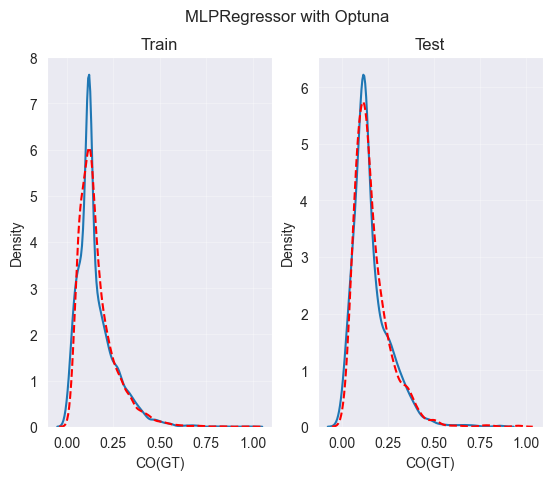

In [22]:

make_graphic(model, "MLPRegressor with Optuna")

По графику видно, что модель хорошо обобщает данные.

In [23]:
print(f"Архитектура сети: {model.hidden_layer_sizes}")

print(f"Количество слоев: {model.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in model.coefs_]}")

Архитектура сети: (100, 100, 100)
Количество слоев: 5
Количество весов (коэффициентов): [(14, 100), (100, 100), (100, 100), (100, 1)]


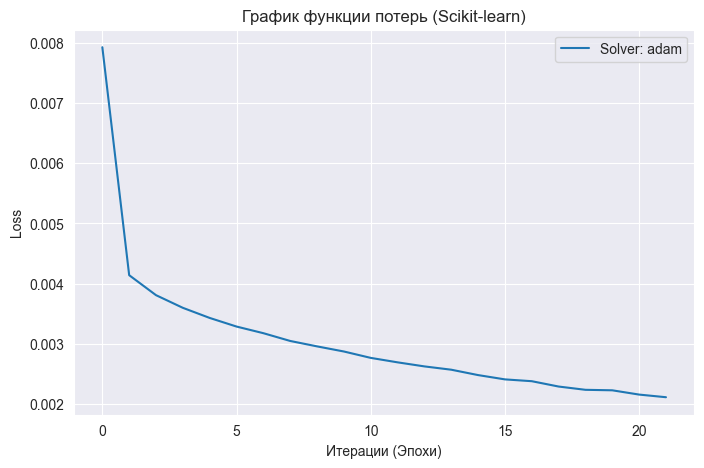

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))


plt.plot(model.loss_curve_, label='Solver: adam')

plt.title('График функции потерь (Scikit-learn)')
plt.xlabel('Итерации (Эпохи)')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

### Структура слоев нейронной сети

* **Входной слой**: 14 нейронов (соответствует количеству входных признаков).
* **Первый скрытый слой**: 100 нейронов.
* **Второй скрытый слой**: 100 нейронов.
* **Третий скрытый слой**: 100 нейронов.
* **Выходной слой**: 1 нейрон (результат регрессии).


### RandomizeSearchCV

In [26]:


solvers = ['adam', 'sgd', 'lbfgs']
best_models_rs = {}

for current_solver in solvers:
    param_dist = {
        'hidden_layer_sizes': [(100,), (50, 50), (100, 50), (100, 100, 100)],
        'activation': ['relu', 'tanh'],
        'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    }

    param_dist['solver'] = [current_solver]

    mlp = MLPRegressor(max_iter=1000, random_state=15)

    rs = RandomizedSearchCV(
        estimator=mlp,
        param_distributions=param_dist,
        n_iter=10,
        n_jobs=-1,
        cv=3,
        scoring="r2",
        verbose=2,
        random_state=15
    )

    rs.fit(X_train, y_train)

    print(f"Лучшие параметры для {current_solver}: {rs.best_params_}")

    best_models_rs[current_solver] = rs.best_estimator_

    model_name = f"MLPRegressor({current_solver})"
    input_into_table(model_name, "RandomizedSearch", rs.best_estimator_, X_train, y_train, X_test, y_test)
table

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Лучшие параметры для adam: {'solver': 'adam', 'hidden_layer_sizes': (100, 100, 100), 'alpha': 1e-05, 'activation': 'tanh'}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Лучшие параметры для sgd: {'solver': 'sgd', 'hidden_layer_sizes': (100, 100, 100), 'alpha': 0.01, 'activation': 'tanh'}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Лучшие параметры для lbfgs: {'solver': 'lbfgs', 'hidden_layer_sizes': (100, 50), 'alpha': 0.01, 'activation': 'relu'}


,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor (adam),Optuna,0.91,0.0009,0.0216,0.87,0.0013,0.0248,19,adam
1,MLPRegressor (sgd),Optuna,0.54,0.0048,0.0518,0.55,0.0046,0.0506,81,sgd
2,MLPRegressor (lbfgs),Optuna,0.91,0.0009,0.0217,0.88,0.0013,0.0241,106,lbfgs
3,MLPRegressor(adam),RandomizedSearch,0.82,0.0019,0.0315,0.82,0.0018,0.0312,15,adam
4,MLPRegressor(sgd),RandomizedSearch,0.51,0.0051,0.0531,0.53,0.0049,0.0520,26,sgd
5,MLPRegressor(lbfgs),RandomizedSearch,0.92,0.0008,0.0206,0.86,0.0014,0.0258,243,lbfgs


Модель, полученная при помощи RandomizedSearch, показывает практически такие же хорошие результаты, как и Optuna. Лучший R2 на тестовой выборке равен 0.86, он был получен при помощи оптимизатора lbfgs.

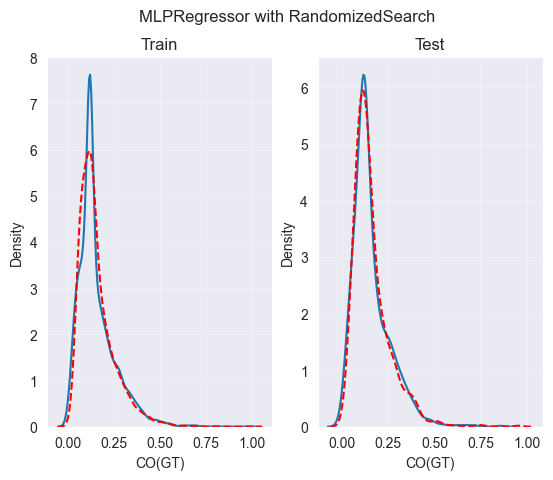

In [28]:
rs_model = best_models_rs["lbfgs"]
make_graphic(rs_model, "MLPRegressor with RandomizedSearch")

In [29]:
print(f"Архитектура сети: {rs_model.hidden_layer_sizes}")

print(f"Количество слоев: {rs_model.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in rs_model.coefs_]}")

Архитектура сети: (100, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(14, 100), (100, 50), (50, 1)]




* **Входной слой**: 14 нейронов (входные признаки).
* **Скрытые слои**: 2 последовательных слоя (первый — 100 нейронов, второй — 50 нейронов).
* **Выходной слой**: 1 нейрон (предсказанное значение).


Так как для lbfgs нет атрибута loss_curve с информацией об изменении ошибки, посмотрим на ошибки двух других оптимизаторов, которые отработали хуже.

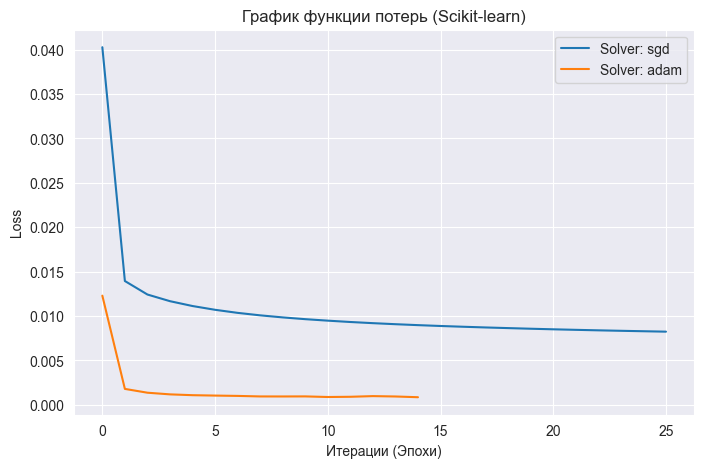

In [46]:
plt.figure(figsize=(8, 5))

for model in [best_models_rs['sgd'], best_models_rs['adam']]:
    plt.plot(model.loss_curve_, label=f'Solver: {model.solver}')

    plt.title('График функции потерь (Scikit-learn)')
    plt.xlabel('Итерации (Эпохи)')
    plt.ylabel('Loss')
    plt.legend()


### Hyperport

In [36]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score

layers = [(100,), (50, 50), (100, 50), (100, 100, 100)]
solvers = ['adam', 'sgd', 'lbfgs']
activations = ['relu', 'tanh']
learning_rates = ['constant', 'adaptive']

best_models_hyperopt = {}

for current_solver in solvers:
    space = {
        'hidden_layer_sizes': hp.choice('hidden_layer_sizes', layers),
        'activation': hp.choice('activation', activations),
        'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(1e-2)),
    }


    def objective(params):
        params['solver'] = current_solver
        model = MLPRegressor(**params, max_iter=1000, random_state=42)
        score = cross_val_score(model, X_train, y_train, cv=3, scoring='r2', n_jobs=-1).mean()
        return {'loss': -score, 'status': STATUS_OK}

    trials = Trials()
    best_indices = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=15, trials=trials, show_progressbar=False)

    best_params = {
        'hidden_layer_sizes': layers[best_indices['hidden_layer_sizes']],
        'solver': current_solver,
        'activation': activations[best_indices['activation']],
        'alpha': best_indices['alpha']
    }

    print(f"Лучшие параметры для {current_solver}: {best_params}")

    best_model = MLPRegressor(**best_params, max_iter=2000, random_state=42).fit(X_train, y_train)
    best_models_hyperopt[current_solver] = best_model

    model_name = f"MLPRegressor ({current_solver})"
    input_into_table(model_name, "Hyperopt", best_model, X_train, y_train, X_test, y_test)
table

Лучшие параметры для adam: {'hidden_layer_sizes': (100, 100, 100), 'solver': 'adam', 'activation': 'relu', 'alpha': 4.182891219312735e-05}
Лучшие параметры для sgd: {'hidden_layer_sizes': (100, 100, 100), 'solver': 'sgd', 'activation': 'tanh', 'alpha': 0.0006508935124656278}
Лучшие параметры для lbfgs: {'hidden_layer_sizes': (100, 100, 100), 'solver': 'lbfgs', 'activation': 'relu', 'alpha': 0.0008210333313818292}


,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor (adam),Optuna,0.91,0.0009,0.0216,0.87,0.0013,0.0248,19,adam
1,MLPRegressor (sgd),Optuna,0.54,0.0048,0.0518,0.55,0.0046,0.0506,81,sgd
2,MLPRegressor (lbfgs),Optuna,0.91,0.0009,0.0217,0.88,0.0013,0.0241,106,lbfgs
3,MLPRegressor(adam),RandomizedSearch,0.82,0.0019,0.0315,0.82,0.0018,0.0312,15,adam
4,MLPRegressor(sgd),RandomizedSearch,0.51,0.0051,0.0531,0.53,0.0049,0.0520,26,sgd
5,MLPRegressor(lbfgs),RandomizedSearch,0.92,0.0008,0.0206,0.86,0.0014,0.0258,243,lbfgs
6,MLPRegressor (adam),Hyperopt,0.91,0.0009,0.0218,0.87,0.0014,0.0257,15,adam
7,MLPRegressor (sgd),Hyperopt,0.60,0.0042,0.0467,0.62,0.0039,0.0451,16,sgd
8,MLPRegressor (lbfgs),Hyperopt,0.90,0.0010,0.0229,0.87,0.0013,0.0252,77,lbfgs


Для Hyperport максимум среди метрик R2 = 0.87. При этом минимальное MSE у оптимизатора lbfgs (=0.0013).

In [37]:
best_model_hyperopt = best_models_hyperopt['lbfgs']

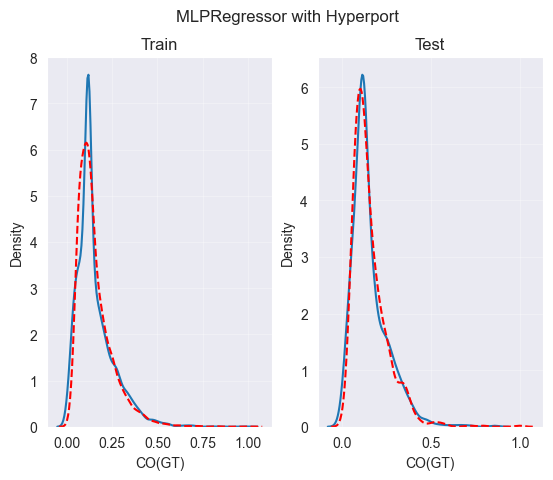

In [38]:
make_graphic(best_model_hyperopt, "MLPRegressor with Hyperport")

In [39]:
print(f"Архитектура сети: {best_model_hyperopt.hidden_layer_sizes}")

print(f"Количество слоев: {best_model_hyperopt.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in best_model_hyperopt.coefs_]}")

Архитектура сети: (100, 100, 100)
Количество слоев: 5
Количество весов (коэффициентов): [(14, 100), (100, 100), (100, 100), (100, 1)]


* **Входной слой**: 14 нейронов (входные признаки).
* **Скрытые слои**: 3 последовательных слоя по 100 нейронов каждый.
* **Выходной слой**: 1 нейрон (предсказанное значение).

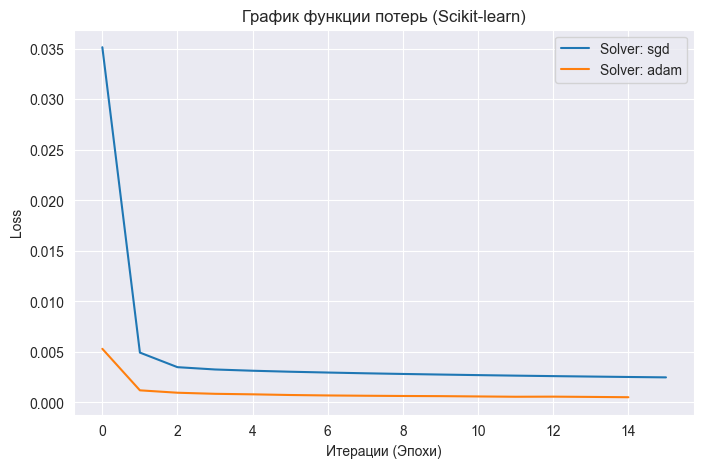

In [48]:

plt.figure(figsize=(8, 5))

for model in [best_models_hyperopt['sgd'], best_models_hyperopt['adam']]:
    plt.plot(model.loss_curve_, label=f'Solver: {model.solver}')

plt.title('График функции потерь (Scikit-learn)')
plt.xlabel('Итерации (Эпохи)')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

## Keras

In [49]:
def input_into_table_keras(name, search_name, model, X_train, y_train, X_test, y_test, history):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    new_row = {
        'Regressor': name,
        'Search strategy': search_name,
        'Train_R2': round(r2_score(y_train, train_pred), 2),
        'Train_MSE': round(mean_squared_error(y_train, train_pred), 4),
        'Train_MAE': round(mean_absolute_error(y_train, train_pred), 4),
        'Test_R2': round(r2_score(y_test, test_pred), 2),
        'Test_MSE': round(mean_squared_error(y_test, test_pred), 4),
        'Test_MAE': round(mean_absolute_error(y_test, test_pred), 4),
        'Epochs': len(history.history['loss']),
        'Solver': model.optimizer.__class__.__name__
    }

    table.loc[len(table)] = new_row


### Optuna

Настроим аналогичные гиперпараметры для модели с API Keras.

In [54]:
solvers = ['adam', 'sgd', 'rmsprop']
best_models_keras_optuna = {}
keras_optuna_history = {}

optimizers_dict = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}


for current_solver in solvers:

    def objective(trial):
        n_layers = trial.suggest_int("n_layers", 1, 5)
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
        activation = trial.suggest_categorical("activation", ["relu", "tanh", "elu"])
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

        kf = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = []

        for train_idx, val_idx in kf.split(X_train):
            X_t, X_v = X_train[train_idx], X_train[val_idx]
            y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model = keras.Sequential()
            model.add(layers.Input(shape=(X_t.shape[1],)))

            for i in range(n_layers):
                num_hidden = trial.suggest_int(f"n_units_l{i}", 16, 512, log=True)
                model.add(layers.Dense(num_hidden, activation=activation))
                dropout_rate = trial.suggest_float(f"dropout_l{i}", 0.0, 0.3)
                model.add(layers.Dropout(dropout_rate))

            model.add(layers.Dense(1, activation="linear"))

            optimizer = optimizers_dict[current_solver](learning_rate=learning_rate)
            model.compile(
                optimizer=optimizer,
                loss="mean_squared_error",
                metrics=["mean_absolute_error"]
            )

            early_stop = keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            )

            model.fit(
                X_t, y_t,
                validation_data=(X_v, y_v),
                epochs=30,
                batch_size=batch_size,
                callbacks=[early_stop],
                verbose=2
            )

            y_pred = model.predict(X_v, verbose=0)
            score = r2_score(y_v, y_pred)
            scores.append(score)

        return np.mean(scores)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=5)

    print(f"Лучшие параметры для {current_solver}: {study.best_params}")

    bp = study.best_params
    final_model = keras.Sequential()
    final_model.add(layers.Input(shape=(X_train.shape[1],)))

    for i in range(bp["n_layers"]):
        final_model.add(layers.Dense(bp[f"n_units_l{i}"], activation=bp["activation"]))
        final_model.add(layers.Dropout(bp[f"dropout_l{i}"]))

    final_model.add(layers.Dense(1, activation="linear"))

    final_optimizer = optimizers_dict[current_solver](learning_rate=bp["learning_rate"])
    final_model.compile(
        optimizer=final_optimizer,
        loss="mean_squared_error",
        metrics=["mean_absolute_error"]
    )

    final_early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = final_model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=40,
        batch_size=bp["batch_size"],
        callbacks=[final_early_stop],
        verbose=2
    )

    keras_optuna_history[current_solver] = history
    best_models_keras_optuna[current_solver] = final_model

    model_name = f"Keras MLP ({current_solver})"
    input_into_table_keras(model_name, "Optuna", final_model, X_train, y_train, X_test, y_test, history)
table

[I 2026-05-16 06:43:56,729] A new study created in memory with name: no-name-161bec15-3d0c-49ab-9d79-d040ad85346c


Epoch 1/30
74/74 - 1s - 13ms/step - loss: 0.0731 - mean_absolute_error: 0.2099 - val_loss: 0.0042 - val_mean_absolute_error: 0.0477
Epoch 2/30
74/74 - 0s - 2ms/step - loss: 0.0448 - mean_absolute_error: 0.1670 - val_loss: 0.0038 - val_mean_absolute_error: 0.0453
Epoch 3/30
74/74 - 0s - 2ms/step - loss: 0.0404 - mean_absolute_error: 0.1582 - val_loss: 0.0037 - val_mean_absolute_error: 0.0447
Epoch 4/30
74/74 - 0s - 2ms/step - loss: 0.0358 - mean_absolute_error: 0.1500 - val_loss: 0.0040 - val_mean_absolute_error: 0.0462
Epoch 5/30
74/74 - 0s - 3ms/step - loss: 0.0322 - mean_absolute_error: 0.1405 - val_loss: 0.0031 - val_mean_absolute_error: 0.0395
Epoch 6/30
74/74 - 0s - 3ms/step - loss: 0.0275 - mean_absolute_error: 0.1304 - val_loss: 0.0033 - val_mean_absolute_error: 0.0413
Epoch 7/30
74/74 - 0s - 2ms/step - loss: 0.0250 - mean_absolute_error: 0.1243 - val_loss: 0.0034 - val_mean_absolute_error: 0.0417
Epoch 8/30
74/74 - 0s - 2ms/step - loss: 0.0234 - mean_absolute_error: 0.1202 - va

[I 2026-05-16 06:44:16,498] Trial 0 finished with value: 0.7242785869137883 and parameters: {'n_layers': 3, 'learning_rate': 9.630547734088717e-05, 'activation': 'tanh', 'batch_size': 64, 'n_units_l0': 20, 'dropout_l0': 0.17521430817475192, 'n_units_l1': 177, 'dropout_l1': 0.11436286214197432, 'n_units_l2': 269, 'dropout_l2': 0.232323932704072}. Best is trial 0 with value: 0.7242785869137883.


Epoch 1/30
148/148 - 1s - 6ms/step - loss: 0.0803 - mean_absolute_error: 0.1809 - val_loss: 0.0031 - val_mean_absolute_error: 0.0379
Epoch 2/30
148/148 - 0s - 1ms/step - loss: 0.0075 - mean_absolute_error: 0.0652 - val_loss: 0.0030 - val_mean_absolute_error: 0.0399
Epoch 3/30
148/148 - 0s - 2ms/step - loss: 0.0047 - mean_absolute_error: 0.0511 - val_loss: 0.0025 - val_mean_absolute_error: 0.0337
Epoch 4/30
148/148 - 0s - 2ms/step - loss: 0.0037 - mean_absolute_error: 0.0445 - val_loss: 0.0025 - val_mean_absolute_error: 0.0333
Epoch 5/30
148/148 - 0s - 2ms/step - loss: 0.0033 - mean_absolute_error: 0.0406 - val_loss: 0.0026 - val_mean_absolute_error: 0.0347
Epoch 6/30
148/148 - 0s - 2ms/step - loss: 0.0030 - mean_absolute_error: 0.0387 - val_loss: 0.0025 - val_mean_absolute_error: 0.0339
Epoch 7/30
148/148 - 0s - 2ms/step - loss: 0.0029 - mean_absolute_error: 0.0375 - val_loss: 0.0024 - val_mean_absolute_error: 0.0324
Epoch 8/30
148/148 - 0s - 2ms/step - loss: 0.0027 - mean_absolute_err

[I 2026-05-16 06:44:36,861] Trial 1 finished with value: 0.7953435896248208 and parameters: {'n_layers': 2, 'learning_rate': 0.007016009321355362, 'activation': 'tanh', 'batch_size': 32, 'n_units_l0': 96, 'dropout_l0': 0.2553985761756814, 'n_units_l1': 31, 'dropout_l1': 0.09233793964308734}. Best is trial 1 with value: 0.7953435896248208.


...

[I 2026-05-16 06:48:32,970] Trial 3 finished with value: 0.7903259111937523 and parameters: {'n_layers': 5, 'learning_rate': 0.006042856673292511, 'activation': 'elu', 'batch_size': 64, 'n_units_l0': 27, 'dropout_l0': 0.1941258637800306, 'n_units_l1': 333, 'dropout_l1': 0.21736180610463118, 'n_units_l2': 424, 'dropout_l2': 0.10374180623316254, 'n_units_l3': 298, 'dropout_l3': 0.019502108282819373, 'n_units_l4': 28, 'dropout_l4': 0.17827260656994587}. Best is trial 2 with value: 0.8124075337104925.


Epoch 1/30
148/148 - 1s - 7ms/step - loss: 0.1788 - mean_absolute_error: 0.3346 - val_loss: 0.0840 - val_mean_absolute_error: 0.2302
Epoch 2/30
148/148 - 0s - 2ms/step - loss: 0.1163 - mean_absolute_error: 0.2688 - val_loss: 0.0359 - val_mean_absolute_error: 0.1476
Epoch 3/30
148/148 - 0s - 2ms/step - loss: 0.0872 - mean_absolute_error: 0.2351 - val_loss: 0.0204 - val_mean_absolute_error: 0.1109
Epoch 4/30
148/148 - 0s - 2ms/step - loss: 0.0727 - mean_absolute_error: 0.2116 - val_loss: 0.0143 - val_mean_absolute_error: 0.0924
Epoch 5/30
148/148 - 0s - 2ms/step - loss: 0.0602 - mean_absolute_error: 0.1950 - val_loss: 0.0110 - val_mean_absolute_error: 0.0799
Epoch 6/30
148/148 - 0s - 2ms/step - loss: 0.0552 - mean_absolute_error: 0.1855 - val_loss: 0.0089 - val_mean_absolute_error: 0.0722
Epoch 7/30
148/148 - 0s - 2ms/step - loss: 0.0490 - mean_absolute_error: 0.1754 - val_loss: 0.0075 - val_mean_absolute_error: 0.0655
Epoch 8/30
148/148 - 0s - 2ms/step - loss: 0.0454 - mean_absolute_err

[I 2026-05-16 06:48:59,396] Trial 4 finished with value: 0.6602446756906519 and parameters: {'n_layers': 5, 'learning_rate': 1.1720156721700399e-05, 'activation': 'tanh', 'batch_size': 32, 'n_units_l0': 32, 'dropout_l0': 0.04933724805056846, 'n_units_l1': 82, 'dropout_l1': 0.2644135258906142, 'n_units_l2': 31, 'dropout_l2': 0.055625023879808, 'n_units_l3': 16, 'dropout_l3': 0.17431902888023296, 'n_units_l4': 67, 'dropout_l4': 0.10632956333062522}. Best is trial 2 with value: 0.8124075337104925.


Лучшие параметры для rmsprop: {'n_layers': 4, 'learning_rate': 0.002139709230117561, 'activation': 'elu', 'batch_size': 32, 'n_units_l0': 18, 'dropout_l0': 0.28186935416844877, 'n_units_l1': 49, 'dropout_l1': 0.27541549771317736, 'n_units_l2': 501, 'dropout_l2': 0.030044180047958256, 'n_units_l3': 27, 'dropout_l3': 0.09429925709951394}
Epoch 1/40
178/178 - 1s - 6ms/step - loss: 0.0770 - mean_absolute_error: 0.1658 - val_loss: 0.0064 - val_mean_absolute_error: 0.0608
Epoch 2/40
178/178 - 0s - 2ms/step - loss: 0.0074 - mean_absolute_error: 0.0646 - val_loss: 0.0029 - val_mean_absolute_error: 0.0375
Epoch 3/40
178/178 - 0s - 2ms/step - loss: 0.0042 - mean_absolute_error: 0.0471 - val_loss: 0.0035 - val_mean_absolute_error: 0.0415
Epoch 4/40
178/178 - 0s - 2ms/step - loss: 0.0033 - mean_absolute_error: 0.0408 - val_loss: 0.0026 - val_mean_absolute_error: 0.0364
Epoch 5/40
178/178 - 0s - 2ms/step - loss: 0.0030 - mean_absolute_error: 0.0386 - val_loss: 0.0024 - val_mean_absolute_error: 0.03

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor (adam),Optuna,0.91,0.0009,0.0216,0.87,0.0013,0.0248,19,adam
1,MLPRegressor (sgd),Optuna,0.54,0.0048,0.0518,0.55,0.0046,0.0506,81,sgd
2,MLPRegressor (lbfgs),Optuna,0.91,0.0009,0.0217,0.88,0.0013,0.0241,106,lbfgs
3,MLPRegressor(adam),RandomizedSearch,0.82,0.0019,0.0315,0.82,0.0018,0.0312,15,adam
4,MLPRegressor(sgd),RandomizedSearch,0.51,0.0051,0.0531,0.53,0.0049,0.0520,26,sgd
5,MLPRegressor(lbfgs),RandomizedSearch,0.92,0.0008,0.0206,0.86,0.0014,0.0258,243,lbfgs
6,MLPRegressor (adam),Hyperopt,0.91,0.0009,0.0218,0.87,0.0014,0.0257,15,adam
7,MLPRegressor (sgd),Hyperopt,0.60,0.0042,0.0467,0.62,0.0039,0.0451,16,sgd
8,MLPRegressor (lbfgs),Hyperopt,0.90,0.0010,0.0229,0.87,0.0013,0.0252,77,lbfgs
9,Keras MLP (adam),Optuna,0.83,0.0018,0.0302,0.83,0.0017,0.0286,40,Adam


Лучшей моделью Keras оказалась модель с оптимизатором adam (r2 = 0.83). Стоит отметить, что для модели keras r2 для всех трех оптимизаторов оказался примерно одинаковым (0.81-0.83).

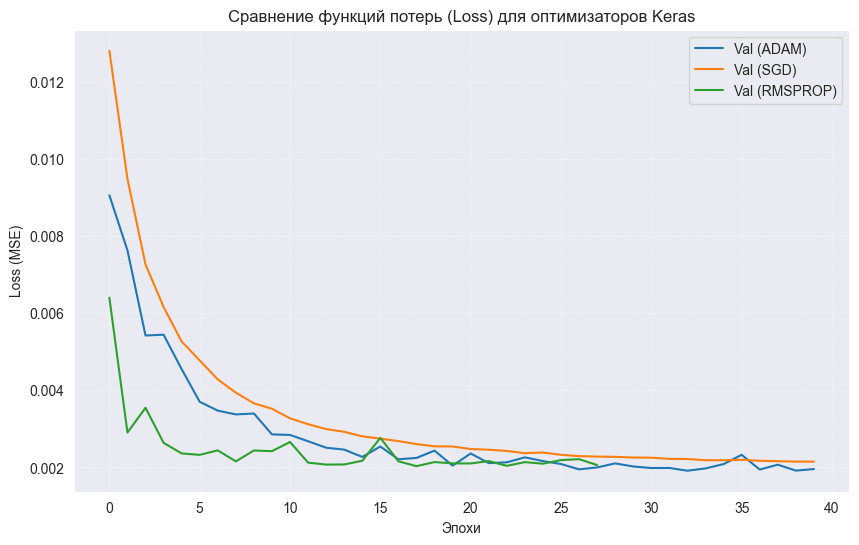

In [58]:
plt.figure(figsize=(10, 6))

for solver_name, history in keras_optuna_history.items():

    metrics = history.history
    plt.plot(metrics['val_loss'], label=f'Val ({solver_name.upper()})', lw=1.5)

plt.title('Сравнение функций потерь (Loss) для оптимизаторов Keras')
plt.xlabel('Эпохи')
plt.ylabel('Loss (MSE)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

Из графика видно, что лучше всего сходится модель adam.

In [59]:
model = best_models_keras_optuna['adam']

In [60]:
model.summary()

Model: "sequential_88"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_363 (Dense)               │ (None, 100)            │         1,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_275 (Dropout)           │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_364 (Dense)               │ (None, 63)             │         6,363 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_276 (Dropout)           │ (None, 63)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_365 (Dense)               │ (None, 1)              │            64 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,783 (92.91 KB)

 Trainable params: 7,927 (30.96 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,856 (61.94 KB)



* **Входной слой**: 14 нейронов.
* **Первый скрытый слой**: 100 нейронов.
* **Второй скрытый слой**: 63 нейрона.
* **Выходной слой**: 1 нейрон.


222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


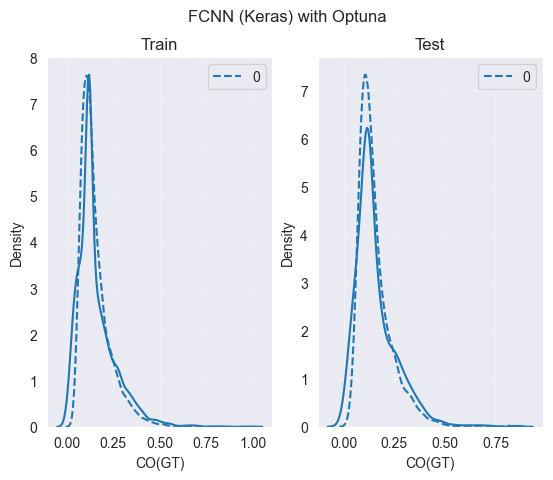

In [61]:
make_graphic(model, "FCNN (Keras) with Optuna")

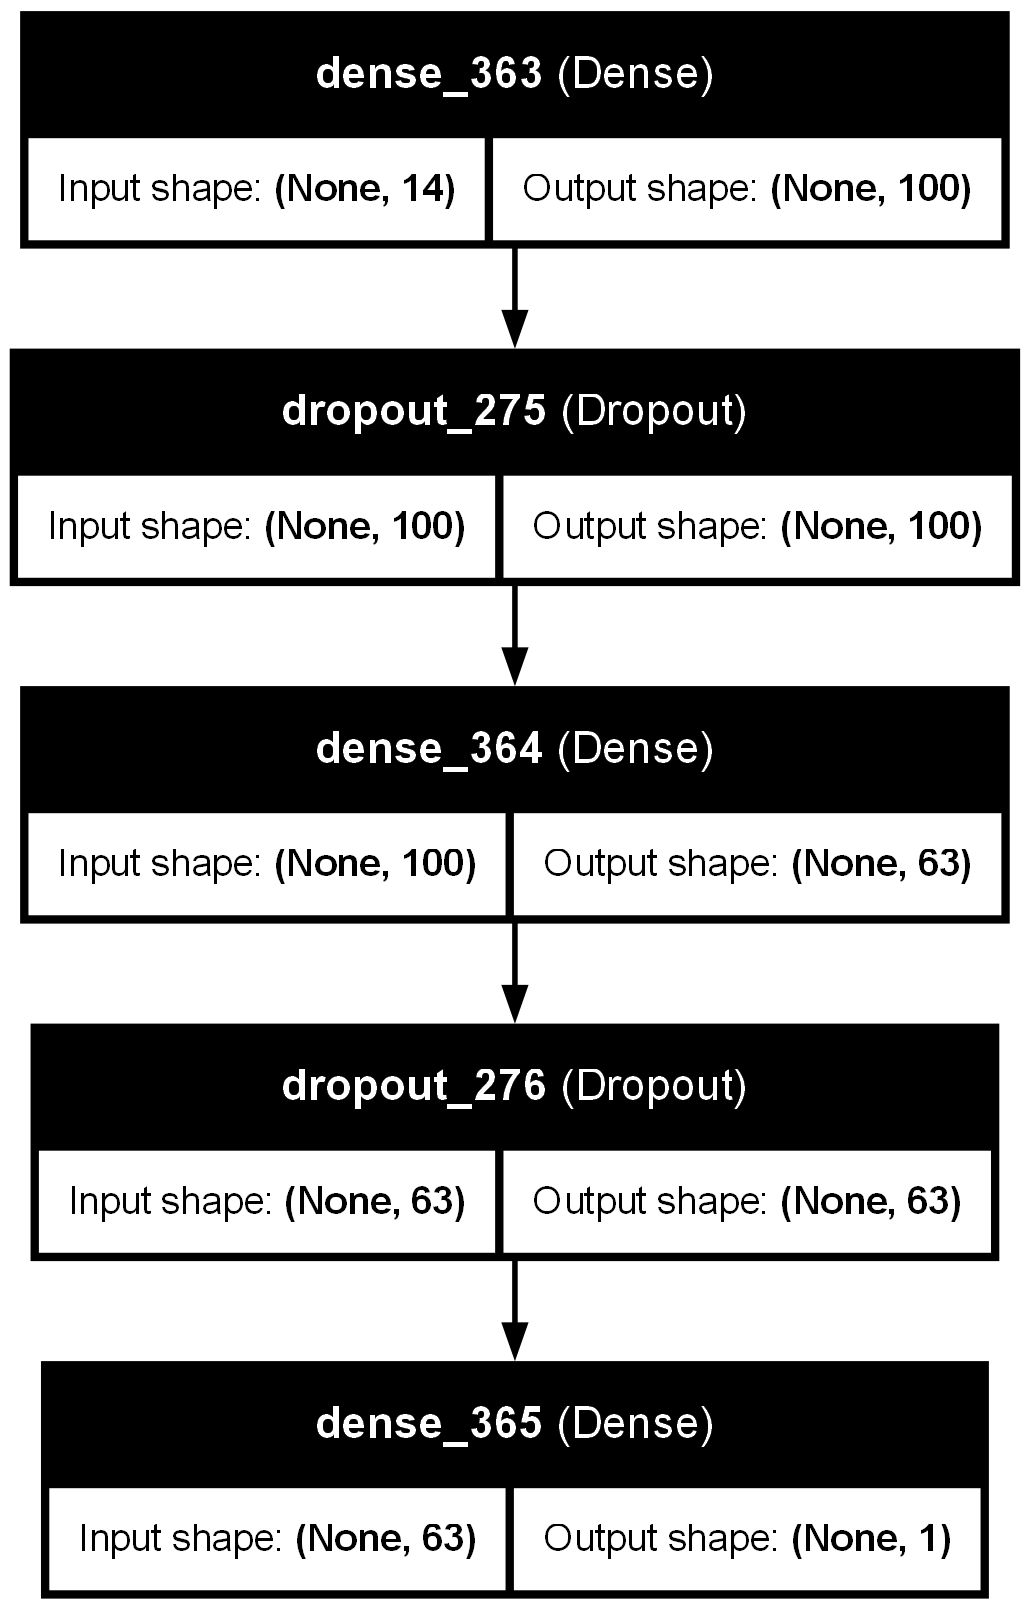

In [4]:
from tensorflow.keras.utils import plot_model

model_to_plot = best_models_keras_optuna['adam']
plot_model(
    model_to_plot,
    to_file='model_plot.png',
    show_shapes=True,
    show_layer_names=True
)

### KerasTuner

In [100]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

solvers = ['adam', 'sgd', 'rmsprop']
best_models_keras_tuner = {}

optimizers_dict = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}

for current_solver in solvers:

    def build_model(hp):
        model = keras.Sequential()
        model.add(layers.Input(shape=(X_train.shape[1],)))

        for i in range(hp.Int("n_layers", 1, 5)):
            model.add(layers.Dense(
                units=hp.Int(f"units_{i}", min_value=32, max_value=512, step=32),
                activation=hp.Choice("activation", ["relu", "tanh", "elu"])
            ))
            if hp.Boolean("dropout"):
                model.add(layers.Dropout(0.2))

        model.add(layers.Dense(1, activation="linear"))

        lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
        optimizer = optimizers_dict[current_solver](learning_rate=lr)

        model.compile(
            optimizer=optimizer,
            loss="mse",
            metrics=["mae"]
        )
        return model

    tuner = kt.RandomSearch(
        build_model,
        objective="val_loss",
        max_trials=10,
        executions_per_trial=1,
        directory="keras_tuner_dir",
        project_name=f"fcnn_tuning_{current_solver}",
        overwrite=True
    )

    tuner.search(
        X_train, y_train,
        epochs=30,
        validation_split=0.2,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)],
        verbose=2
    )

    best_hp = tuner.get_best_hyperparameters()[0]
    print(f"Лучшие параметры для {current_solver}: {best_hp.values}")

    final_model = tuner.get_best_models(num_models=1)[0]

    history = final_model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=2
    )

    best_models_keras_tuner[current_solver] = final_model

    model_name = f"Keras MLP ({current_solver})"
    input_into_table_keras(model_name, "KerasTuner", final_model, X_train, y_train, X_test, y_test, history)


Trial 10 Complete [00h 00m 05s]
val_loss: 0.00924699380993843

Best val_loss So Far: 0.0015296470373868942
Total elapsed time: 00h 01m 15s
Лучшие параметры для rmsprop: {'n_layers': 4, 'units_0': 480, 'activation': 'relu', 'dropout': False, 'lr': 0.00024042158263377529, 'units_1': 32, 'units_2': 416, 'units_3': 512, 'units_4': 160}
Epoch 1/50


C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


178/178 - 1s - 5ms/step - loss: 0.0014 - mae: 0.0263 - val_loss: 0.0018 - val_mae: 0.0292
Epoch 2/50
178/178 - 0s - 2ms/step - loss: 0.0013 - mae: 0.0257 - val_loss: 0.0015 - val_mae: 0.0271
Epoch 3/50
178/178 - 0s - 2ms/step - loss: 0.0013 - mae: 0.0249 - val_loss: 0.0015 - val_mae: 0.0263
Epoch 4/50
178/178 - 0s - 2ms/step - loss: 0.0012 - mae: 0.0246 - val_loss: 0.0015 - val_mae: 0.0269
Epoch 5/50
178/178 - 0s - 2ms/step - loss: 0.0012 - mae: 0.0244 - val_loss: 0.0015 - val_mae: 0.0260
Epoch 6/50
178/178 - 0s - 2ms/step - loss: 0.0012 - mae: 0.0241 - val_loss: 0.0016 - val_mae: 0.0270
Epoch 7/50
178/178 - 0s - 2ms/step - loss: 0.0011 - mae: 0.0235 - val_loss: 0.0015 - val_mae: 0.0260
Epoch 8/50
178/178 - 0s - 2ms/step - loss: 0.0011 - mae: 0.0233 - val_loss: 0.0016 - val_mae: 0.0271
Epoch 9/50
178/178 - 0s - 2ms/step - loss: 0.0011 - mae: 0.0233 - val_loss: 0.0016 - val_mae: 0.0268
Epoch 10/50
178/178 - 0s - 2ms/step - loss: 0.0010 - mae: 0.0226 - val_loss: 0.0018 - val_mae: 0.0294


In [103]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor (adam),Optuna,0.91,0.0009,0.0216,0.87,0.0013,0.0248,19,adam
1,MLPRegressor (sgd),Optuna,0.54,0.0048,0.0518,0.55,0.0046,0.0506,81,sgd
2,MLPRegressor (lbfgs),Optuna,0.91,0.0009,0.0217,0.88,0.0013,0.0241,106,lbfgs
3,MLPRegressor(adam),RandomizedSearch,0.82,0.0019,0.0315,0.82,0.0018,0.0312,15,adam
4,MLPRegressor(sgd),RandomizedSearch,0.51,0.0051,0.0531,0.53,0.0049,0.0520,26,sgd
5,MLPRegressor(lbfgs),RandomizedSearch,0.92,0.0008,0.0206,0.86,0.0014,0.0258,243,lbfgs
6,MLPRegressor (adam),Hyperopt,0.91,0.0009,0.0218,0.87,0.0014,0.0257,15,adam
7,MLPRegressor (sgd),Hyperopt,0.60,0.0042,0.0467,0.62,0.0039,0.0451,16,sgd
8,MLPRegressor (lbfgs),Hyperopt,0.90,0.0010,0.0229,0.87,0.0013,0.0252,77,lbfgs
9,Keras MLP (adam),Optuna,0.83,0.0018,0.0302,0.83,0.0017,0.0286,40,Adam


Оптимизатор adam показал лучший результат R2 = 0.89.

C:\Users\79585\AppData\Local\Temp\ipykernel_2344\4176540327.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


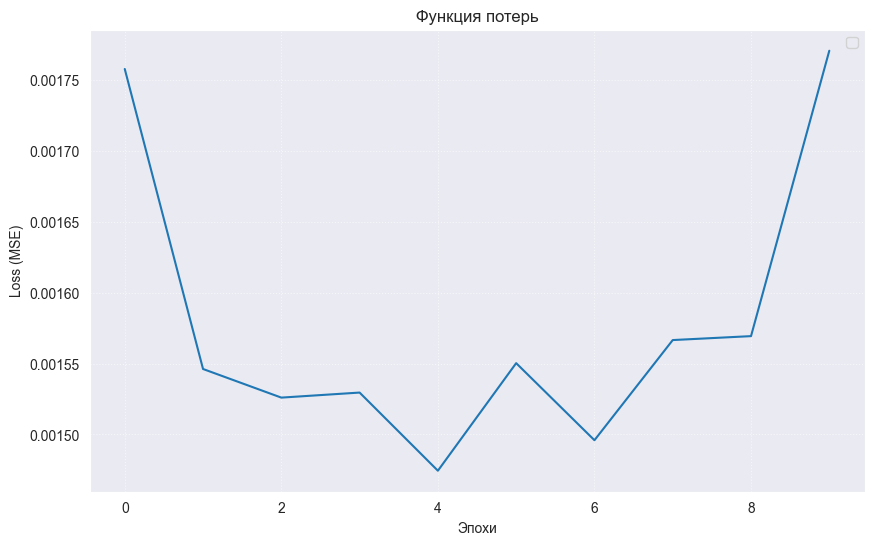

In [105]:
plt.figure(figsize=(10, 6))

metrics = history.history
plt.plot(metrics['val_loss'], lw=1.5)

plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Loss (MSE)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

По графику видно, что процесс обучения с KerasTuner нестабилен - есть сильные колебания ошибки на протяжении всех эпох.

222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


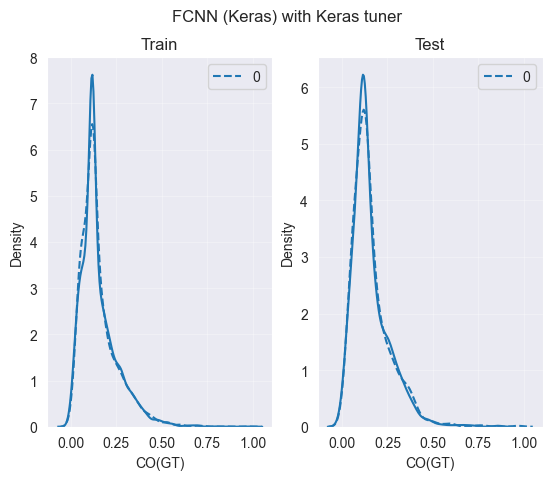

In [106]:
best_model = best_models_keras_tuner['adam']
make_graphic(best_model, "FCNN (Keras) with Keras tuner")

In [107]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 448)            │         6,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 160)            │        71,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,469 (1.23 MB)

 Trainable params: 107,489 (419.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 214,980 (839.77 KB)

* **Входной слой**: 14 нейронов.
* **Первый скрытый слой**: 448 нейронов.
* **Второй скрытый слой**: 160 нейронов.
* **Третий скрытый слой**: 128 нейронов.
* **Четвертый скрытый слой**: 64 нейрона.





### RayTune

In [109]:
y_train = np.array(y_train)

In [125]:
from ray import tune
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import numpy as np
def get_model_ray(opt):
    def train_model_ray(config):

        kf = KFold(n_splits=3, shuffle=True, random_state=42)
        fold_results = []


        for train_idx, val_idx in kf.split(X_train):
            X_t, X_v = X_train[train_idx], X_train[val_idx]
            y_t, y_v = y_train[train_idx], y_train[val_idx]

            model = Sequential()
            model.add(layers.Input(shape=(X_t.shape[1],)))

            for i in range(config["n_layers"]):
                model.add(layers.Dense(
                    units=config[f"units_{i}"],
                    activation=config["activation"]
                ))
                if config["dropout"]:
                    model.add(layers.Dropout(0.2))

            model.add(layers.Dense(1, activation="linear"))

            optimizer = opt(learning_rate=config["lr"])
            model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

            history = model.fit(
                X_t, y_t,
                epochs=15,
                batch_size=32,
                validation_data=(X_v, y_v),
                verbose=0
            )

            fold_results.append(min(history.history["val_mae"]))

        mean_mae = float(np.mean(fold_results))
        tune.report({"val_mae": mean_mae})


    search_space = {
        "n_layers": tune.randint(1, 6),
        "activation": tune.choice(["relu", "tanh", "elu"]),
        "dropout": tune.choice([True, False]),
        "lr": tune.loguniform(1e-4, 1e-2),
        "optimizer": tune.choice(list(optimizers_dict.keys())),
    }


    for i in range(5):
        search_space[f"units_{i}"] = tune.qrandint(32, 512, 32)


    tuner = tune.Tuner(
        train_model_ray,
        param_space=search_space,
        tune_config=tune.TuneConfig(
            metric="val_mae",
            mode="min",
            num_samples=5
        )
    )

    results = tuner.fit()
    print("Лучшие параметры:", results.get_best_result().config)
    config = results.get_best_result().config
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    for i in range(config["n_layers"]):
        model.add(layers.Dense(
            units=config[f"units_{i}"],
            activation=config["activation"]
        ))
        if config["dropout"]:
            model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1, activation="linear"))


    optimizer = opt(learning_rate=config["lr"])
    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])


    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=1
    )

    input_into_table_keras(
        name="FCNN (Keras)",
        search_name="Ray Tune",
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        history=history
    )

    return model, history

adam_history, adam_model = get_model_ray(tf.keras.optimizers.Adam)



2026-05-16 07:42:10,254	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-42-10\train_model_ray_2026-05-16_07-42-10\driver_artifacts\train_model_ray_746b5_00000_0_activation=tanh,dropout=True,lr=0.0008,n_layers=4,optimizer=adam,units_0=96,units_1=288,units_2=320,_2026-05-16_07-42-10
2026-05-16 07:42:10,260	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-42-10\train_model_ray_2026-05-16_07-42-10\driver_artifacts\train_model_ray_746b5_00000_0_activation=tanh,dropout=True,lr=0.0008,n_layers=4,optimizer=adam,units_0=96,units_1=288,units_2=320,_2026-05-16_07-42-10
2026-05-16 07:42

2026-05-16 07:42:18,728	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-42-10\train_model_ray_2026-05-16_07-42-10\driver_artifacts\train_model_ray_746b5_00002_2_activation=relu,dropout=False,lr=0.0034,n_layers=5,optimizer=adam,units_0=256,units_1=96,units_2=352_2026-05-16_07-42-10
2026-05-16 07:42:18,758	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-42-10\train_model_ray_2026-05-16_07-42-10\driver_artifacts\train_model_ray_746b5_00000_0_activation=tanh,dropout=True,lr=0.0008,n_layers=4,optimizer=adam,units_0=96,units_1=288,units_2=320,_2026-05-16_07-42-10
2026-05-16 07:42

Лучшие параметры: {'n_layers': 5, 'activation': 'relu', 'dropout': False, 'lr': 0.0034142126138209513, 'optimizer': 'adam', 'units_0': 256, 'units_1': 96, 'units_2': 352, 'units_3': 416, 'units_4': 352}
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0249 - mae: 0.0725 - val_loss: 0.0021 - val_mae: 0.0343
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0020 - mae: 0.0322 - val_loss: 0.0019 - val_mae: 0.0309
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018 - mae: 0.0296 - val_loss: 0.0017 - val_mae: 0.0288
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0016 - mae: 0.0281 - val_loss: 0.0018 - val_mae: 0.0295
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018 - mae: 0.0295 - val_loss: 0.0019 - val_mae: 0.0306
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0017 - mae: 0.0286 - val_loss: 0.0016 - val_mae: 0.0280
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015 - mae: 0.0269 - val_lo

In [126]:
s_history, s_model = get_model_ray(tf.keras.optimizers.SGD)

2026-05-16 07:43:44,361	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-43-44\train_model_ray_2026-05-16_07-43-44\driver_artifacts\train_model_ray_ac80f_00000_0_activation=tanh,dropout=True,lr=0.0052,n_layers=5,optimizer=adam,units_0=192,units_1=320,units_2=256_2026-05-16_07-43-44
2026-05-16 07:43:44,368	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-43-44\train_model_ray_2026-05-16_07-43-44\driver_artifacts\train_model_ray_ac80f_00000_0_activation=tanh,dropout=True,lr=0.0052,n_layers=5,optimizer=adam,units_0=192,units_1=320,units_2=256_2026-05-16_07-43-44
2026-05-16 07:43

2026-05-16 07:43:52,465	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-43-44\train_model_ray_2026-05-16_07-43-44\driver_artifacts\train_model_ray_ac80f_00000_0_activation=tanh,dropout=True,lr=0.0052,n_layers=5,optimizer=adam,units_0=192,units_1=320,units_2=256_2026-05-16_07-43-44
2026-05-16 07:43:52,920	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-43-44\train_model_ray_2026-05-16_07-43-44\driver_artifacts\train_model_ray_ac80f_00001_1_activation=elu,dropout=True,lr=0.0016,n_layers=5,optimizer=sgd,units_0=128,units_1=224,units_2=32,un_2026-05-16_07-43-44
2026-05-16 07:43

Лучшие параметры: {'n_layers': 5, 'activation': 'tanh', 'dropout': True, 'lr': 0.005202661671249582, 'optimizer': 'adam', 'units_0': 192, 'units_1': 320, 'units_2': 256, 'units_3': 288, 'units_4': 288}
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1371 - mae: 0.2893 - val_loss: 0.0051 - val_mae: 0.0546
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0574 - mae: 0.1878 - val_loss: 0.0030 - val_mae: 0.0369
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0406 - mae: 0.1589 - val_loss: 0.0029 - val_mae: 0.0366
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0329 - mae: 0.1419 - val_loss: 0.0028 - val_mae: 0.0360
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0277 - mae: 0.1305 - val_loss: 0.0028 - val_mae: 0.0359
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0235 - mae: 0.1206 - val_loss: 0.0028 - val_mae: 0.0357
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0215 - mae: 0.1144 - val_los

In [127]:
rms_history, rms_model = get_model_ray(tf.keras.optimizers.RMSprop)

2026-05-16 07:45:01,013	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-45-00\train_model_ray_2026-05-16_07-45-00\driver_artifacts\train_model_ray_da313_00000_0_activation=tanh,dropout=False,lr=0.0080,n_layers=4,optimizer=adam,units_0=96,units_1=352,units_2=128_2026-05-16_07-45-01
2026-05-16 07:45:01,020	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-45-00\train_model_ray_2026-05-16_07-45-00\driver_artifacts\train_model_ray_da313_00000_0_activation=tanh,dropout=False,lr=0.0080,n_layers=4,optimizer=adam,units_0=96,units_1=352,units_2=128_2026-05-16_07-45-01
2026-05-16 07:45

2026-05-16 07:45:09,188	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-45-00\train_model_ray_2026-05-16_07-45-00\driver_artifacts\train_model_ray_da313_00000_0_activation=tanh,dropout=False,lr=0.0080,n_layers=4,optimizer=adam,units_0=96,units_1=352,units_2=128_2026-05-16_07-45-01
2026-05-16 07:45:09,206	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_07-22-57_251590_2344\artifacts\2026-05-16_07-45-00\train_model_ray_2026-05-16_07-45-00\driver_artifacts\train_model_ray_da313_00001_1_activation=relu,dropout=True,lr=0.0002,n_layers=3,optimizer=adam,units_0=384,units_1=256,units_2=192_2026-05-16_07-45-01
2026-05-16 07:45

Лучшие параметры: {'n_layers': 1, 'activation': 'tanh', 'dropout': False, 'lr': 0.0009045162676334934, 'optimizer': 'sgd', 'units_0': 320, 'units_1': 192, 'units_2': 128, 'units_3': 384, 'units_4': 160}
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0167 - mae: 0.0846 - val_loss: 0.0037 - val_mae: 0.0468
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0080 - mae: 0.0640 - val_loss: 0.0069 - val_mae: 0.0684
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0079 - mae: 0.0643 - val_loss: 0.0029 - val_mae: 0.0374
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0064 - mae: 0.0591 - val_loss: 0.0042 - val_mae: 0.0507
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0066 - mae: 0.0603 - val_loss: 0.0049 - val_mae: 0.0550
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0052 - mae: 0.0525 - val_loss: 0.0037 - val_mae: 0.0481
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0049 - mae: 0.0513 - val_lo

In [128]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor (adam),Optuna,0.91,0.0009,0.0216,0.87,0.0013,0.0248,19,adam
1,MLPRegressor (sgd),Optuna,0.54,0.0048,0.0518,0.55,0.0046,0.0506,81,sgd
2,MLPRegressor (lbfgs),Optuna,0.91,0.0009,0.0217,0.88,0.0013,0.0241,106,lbfgs
3,MLPRegressor(adam),RandomizedSearch,0.82,0.0019,0.0315,0.82,0.0018,0.0312,15,adam
4,MLPRegressor(sgd),RandomizedSearch,0.51,0.0051,0.0531,0.53,0.0049,0.0520,26,sgd
5,MLPRegressor(lbfgs),RandomizedSearch,0.92,0.0008,0.0206,0.86,0.0014,0.0258,243,lbfgs
6,MLPRegressor (adam),Hyperopt,0.91,0.0009,0.0218,0.87,0.0014,0.0257,15,adam
7,MLPRegressor (sgd),Hyperopt,0.60,0.0042,0.0467,0.62,0.0039,0.0451,16,sgd
8,MLPRegressor (lbfgs),Hyperopt,0.90,0.0010,0.0229,0.87,0.0013,0.0252,77,lbfgs
9,Keras MLP (adam),Optuna,0.83,0.0018,0.0302,0.83,0.0017,0.0286,40,Adam


Лучшие результаты снова показал оптимизатор adam (R2 = 0.89).

In [130]:
adam_history.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 96)             │        24,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 352)            │        34,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 416)            │       146,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 352)            │       146,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,069,925 (4.08 MB)

 Trainable params: 356,641 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 713,284 (2.72 MB)



* **Входной слой**: 14 нейронов.
* **Первый скрытый слой**: 256 нейронов.
* **Второй скрытый слой**: 96 нейронов.
* **Третий скрытый слой**: 352 нейрона.
* **Четвертый скрытый слой**: 416 нейронов.
* **Пятый скрытый слой**: 352 нейрона.
* **Выходной слой**: 1 нейрон (линейная регрессия).




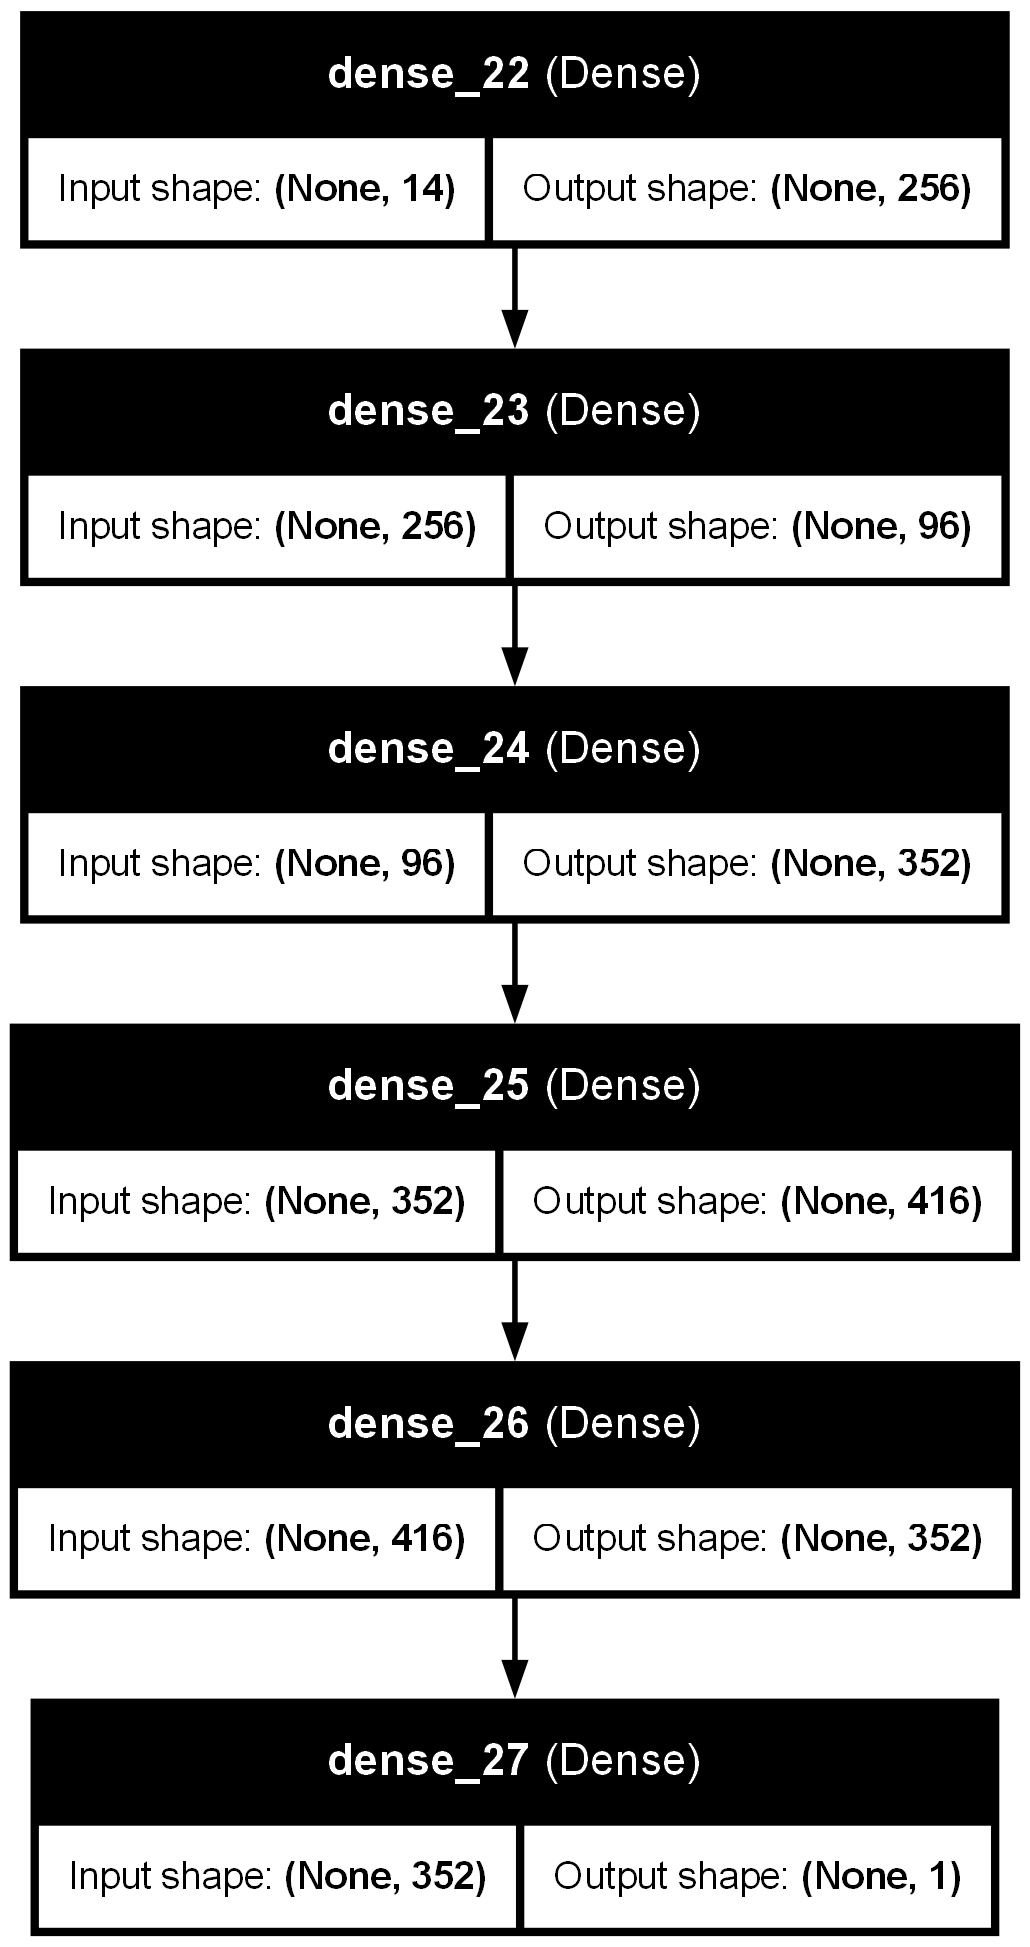

In [6]:
plot_model(
    adam_history,
    to_file='model_plot.png',
    show_shapes=True,
    show_layer_names=True
)

Text(0, 0.5, 'Loss (MSE)')

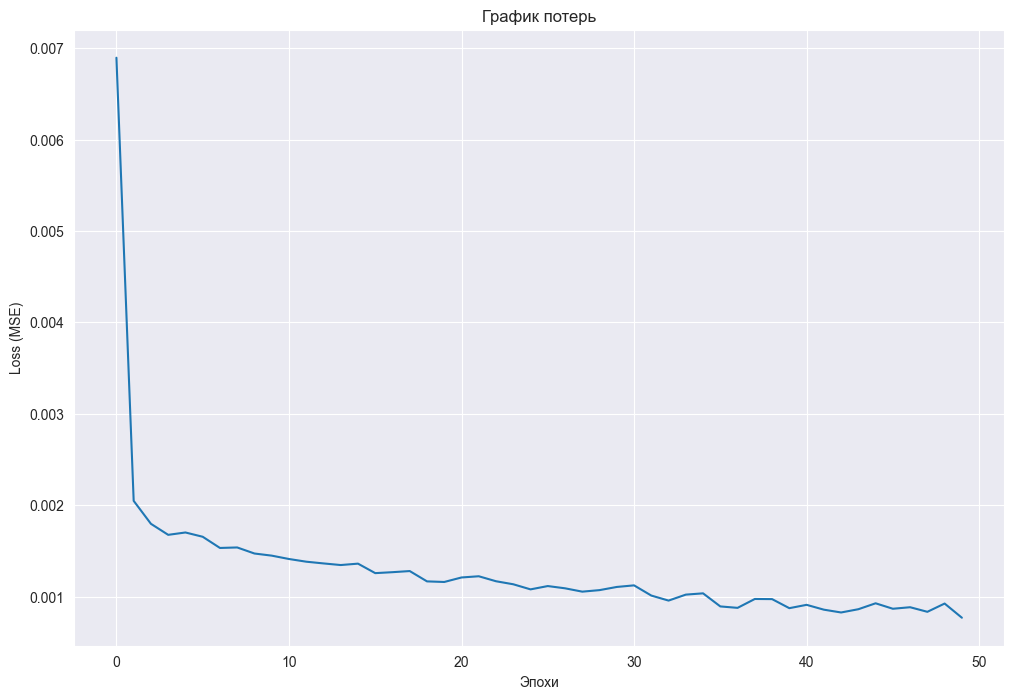

In [131]:
plt.figure(figsize=(12, 8))
plt.plot(adam_model.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss (MSE)")

Видим, что модель минимизировала ошибку за число эпох, меньшее чем 30.

222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


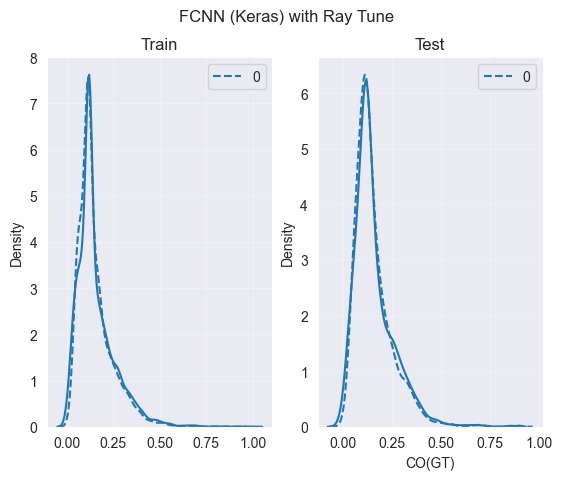

In [132]:
make_graphic(adam_history, "FCNN (Keras) with Ray Tune")

## Вывод

In [133]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor (adam),Optuna,0.91,0.0009,0.0216,0.87,0.0013,0.0248,19,adam
1,MLPRegressor (sgd),Optuna,0.54,0.0048,0.0518,0.55,0.0046,0.0506,81,sgd
2,MLPRegressor (lbfgs),Optuna,0.91,0.0009,0.0217,0.88,0.0013,0.0241,106,lbfgs
3,MLPRegressor(adam),RandomizedSearch,0.82,0.0019,0.0315,0.82,0.0018,0.0312,15,adam
4,MLPRegressor(sgd),RandomizedSearch,0.51,0.0051,0.0531,0.53,0.0049,0.0520,26,sgd
5,MLPRegressor(lbfgs),RandomizedSearch,0.92,0.0008,0.0206,0.86,0.0014,0.0258,243,lbfgs
6,MLPRegressor (adam),Hyperopt,0.91,0.0009,0.0218,0.87,0.0014,0.0257,15,adam
7,MLPRegressor (sgd),Hyperopt,0.60,0.0042,0.0467,0.62,0.0039,0.0451,16,sgd
8,MLPRegressor (lbfgs),Hyperopt,0.90,0.0010,0.0229,0.87,0.0013,0.0252,77,lbfgs
9,Keras MLP (adam),Optuna,0.83,0.0018,0.0302,0.83,0.0017,0.0286,40,Adam


Лучшей моделью оказалась модель Keras, полученная с помощью KerasTune (R2 = 0.89) c оптимизатором Adam. Метрика R2 оказалась хуже метрики R2 модели CatBoost, построенной в ходе предыдущих лабораторных работ (для нее R2 = 0.94, MSE = 0.0007).

В целом стоит отметить, что нейросетевой подход хорошо подошел для этих данных, так как практически для всех способов построения нейросети значение метрики R2 превышает 0.75.

In [5]:
import pickle
with open('adam_ray_dict.pkl', 'rb') as f:
    adam_history = pickle.load(f)

In [6]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasRegressor

best_model = adam_history

keras_regressor = KerasRegressor(
    model=best_model,
    epochs=100,
    batch_size=32,
    verbose=2
)

pipeline = Pipeline([
    ('minmax', MinMaxScaler()),
    ('selector', VarianceThreshold(threshold=0.015)),
    ('scaler', StandardScaler()),
    ('keras', keras_regressor)
])

pipeline.fit(X,y)

Epoch 1/100
278/278 - 1s - 5ms/step - loss: 0.0014 - mae: 0.0265
Epoch 2/100
278/278 - 1s - 2ms/step - loss: 0.0014 - mae: 0.0264
Epoch 3/100
278/278 - 1s - 2ms/step - loss: 0.0014 - mae: 0.0262
Epoch 4/100
278/278 - 1s - 2ms/step - loss: 0.0014 - mae: 0.0261
Epoch 5/100
278/278 - 1s - 2ms/step - loss: 0.0013 - mae: 0.0259
Epoch 6/100
278/278 - 1s - 2ms/step - loss: 0.0013 - mae: 0.0258
Epoch 7/100
278/278 - 1s - 2ms/step - loss: 0.0013 - mae: 0.0256
Epoch 8/100
278/278 - 1s - 2ms/step - loss: 0.0013 - mae: 0.0254
Epoch 9/100
278/278 - 1s - 2ms/step - loss: 0.0013 - mae: 0.0258
Epoch 10/100
278/278 - 1s - 2ms/step - loss: 0.0013 - mae: 0.0253
Epoch 11/100
278/278 - 1s - 2ms/step - loss: 0.0013 - mae: 0.0253
Epoch 12/100
278/278 - 1s - 2ms/step - loss: 0.0013 - mae: 0.0252
Epoch 13/100
278/278 - 1s - 2ms/step - loss: 0.0012 - mae: 0.0251
Epoch 14/100
278/278 - 1s - 2ms/step - loss: 0.0012 - mae: 0.0250
Epoch 15/100
278/278 - 1s - 2ms/step - loss: 0.0013 - mae: 0.0252
Epoch 16/100
278/27

Pipeline(steps=[('minmax', MinMaxScaler()),
                ('selector', VarianceThreshold(threshold=0.015)),
                ('scaler', StandardScaler()),
                ('keras',
                 KerasRegressor(batch_size=32, epochs=100, model=<Sequential name=sequential, built=True>, verbose=2))])

In [21]:
air_quality_object = {
    'PT08.S1(CO)': [1.0],
    'C6H6(GT)': [9.4],
    'PT08.S2(NMHC)': [95.0],
    'NOx(GT)': [11.0],
    'NO2(GT)': [18.0],
    'PT08.S4(NO2)': [14.0],
    'PT08.S5(O3)': [10.0],
    'T': [18.5],
    'RH': [48.2],
    'AH': [0.75],
    'day': [0.3],
    'month': [5],
    'day_of_week': [2],
    'hour': [14],
    'year': [2014]
}
air_quality_df = pd.DataFrame(air_quality_object)
pipeline.predict(air_quality_df)

1/1 - 0s - 25ms/step


array([8.2985525], dtype=float32)

Получили повышенное содержание CO в воздухе из-за повышенных показаний датчиков, переданных в предикторах.